In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning EDA Concepts

Before training a Machine Learning model, it is important to understand a few basic terms that will be used throughout this notebook.

| Term | Meaning |
|------|---------|
| Dataset | A collection of records used to train and test a machine learning model. |
| Feature | An input variable used by the model to make predictions. |
| Target Variable | The output variable that the model learns to predict. |
| Numerical Feature | A feature containing numeric values such as Age, Marks, or Attendance. |
| Categorical Feature | A feature containing categories or text such as Gender or Department. |
| Distribution | The way values are spread within a feature. |
| Outlier | An unusually high or low value compared to the rest of the data. |
| Correlation | The relationship between two numerical features. |
| Feature Selection | The process of choosing the most useful input features for model training. |
| Feature Scaling | Adjusting numerical values to a similar range before training certain machine learning models. |
| Encoding | Converting categorical (text) data into numerical values so that a machine learning model can process it. |

#### Feature Scaling

Feature Scaling is the process of transforming numerical features so that they have a similar range or scale.

##### Example

Suppose we have two features:

| Feature | Values |
|---------|--------|
| Age | 18, 20, 22, 25 |
| Tuition Fee | 50,000, 75,000, 100,000 |

Notice that **Age** ranges from **18–25**, while **Tuition Fee** ranges from **50,000–100,000**.

Because Tuition Fee has much larger values, some Machine Learning algorithms may give it more importance than Age, even if Age is equally important for prediction.

Feature Scaling brings numerical features to a similar scale so that each feature contributes fairly during model training.

##### Why It Matters

- Prevents features with large values from dominating the model.
- Improves the performance of many Machine Learning algorithms.
- Helps models converge faster during training.
- Produces more reliable predictions.

##### Common Feature Scaling Techniques

- Standardization (StandardScaler)
- Normalization (MinMaxScaler)

> **Note:** Feature Scaling is applied only to numerical features and is usually performed after data cleaning and before model training.

#### Do All Machine Learning Models Require Feature Scaling?

No. Feature Scaling is important for some Machine Learning algorithms but not for all.

| Feature Scaling Required | Feature Scaling Usually Not Required |
|--------------------------|--------------------------------------|
| K-Nearest Neighbors (KNN) | Decision Tree |
| K-Means Clustering | Random Forest |
| Support Vector Machine (SVM) | XGBoost |
| Logistic Regression | LightGBM |
| Linear Regression | CatBoost |
| Neural Networks (Deep Learning) | Naïve Bayes (usually) |

For Deep Learning models such as Artificial Neural Networks (ANNs), Convolutional Neural Networks (CNNs), and Recurrent Neural Networks (RNNs), feature scaling is strongly recommended because it improves training speed and model performance.

In [17]:
# Load the cleaned dataset
df = pd.read_csv("student_performance_cleaned.csv")

In [18]:
# Display the first five rows
df.head()

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee
0,2024001,Muhammad Khan,male,20,SE,4,67,80.800000,Bannu,2024-01-22,muhammad.khan2024001@itar.edu.pk,Yes,15000.0
1,2024002,Ali Khan,male,23,DS,6,77,86.600000,Kohat,2024-04-30,ali.khan2024002@itar.edu.pk,No,30000.0
2,2024003,Ahmad Khan,male,18,CS,1,70,85.100000,Peshawar,2024-12-08,ahmad.khan2024003@itar.edu.pk,No,50000.0
3,2024004,Hamza Khan,male,19,DS,2,71,85.200000,Bannu,2024-12-08,hamza.khan2024004@itar.edu.pk,No,30000.0
4,2024005,Abdullah Khan,male,18,AI,1,82,84.205941,Mardan,2024-01-01,abdullah.khan2024005@itar.edu.pk,Yes,25000.0


In [19]:
# Count non-missing values in each column
df.count()

student_id               145
full_name                145
gender                   145
age                      145
department               145
semester                 145
marks                    145
attendance_percentage    145
city                     145
admission_date           145
email                    145
scholarship              145
tuition_fee              145
dtype: int64

#### **Target Variable**

- The **target variable** is the column that a Machine Learning model learns to predict.

- A dataset may contain many columns, but for a single Machine Learning problem, we usually select **one target variable**. All remaining relevant columns become **features** (input variables).

- The choice of the target variable depends on the problem we want to solve.

> **Important**

A dataset can contain many columns, but for a single Machine Learning model, we usually choose **one target variable**.

> If we want to solve a different prediction problem, we simply select a different target variable and train a new model.

| Prediction Task     | Target Variable       | Features                                                   |
| ------------------- | --------------------- | ---------------------------------------------------------- |
| Predict Marks       | Marks                 | Age, Gender, Semester, Attendance, Department, Tuition Fee |
| Predict Scholarship | Scholarship           | Age, Gender, Semester, Marks, Attendance, Department       |
| Predict Department  | Department            | Age, Gender, Semester, Marks, Attendance                   |
| Predict Attendance  | Attendance Percentage | Age, Gender, Semester, Department, Marks                   |


In [20]:
# Display summary statistics of the target variable
df["marks"].describe()

count    145.000000
mean      78.875862
std       11.455156
min       12.000000
25%       73.000000
50%       80.000000
75%       86.000000
max       98.000000
Name: marks, dtype: float64

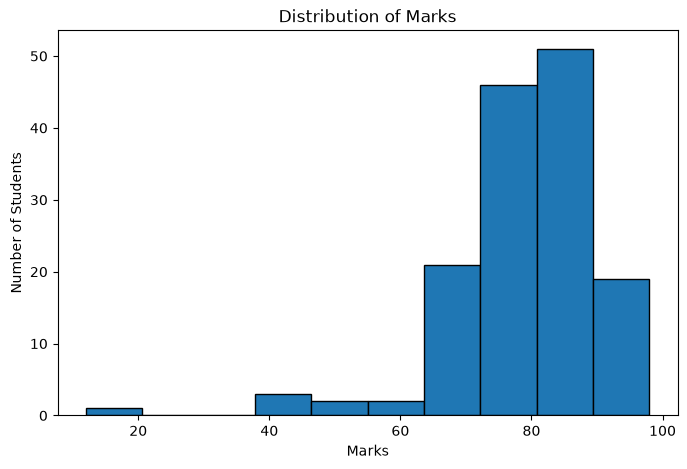

In [21]:
# Plot the distribution of marks
plt.figure(figsize=(8,5))
plt.hist(df["marks"], bins=10, edgecolor="black")
plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

#### What to Observe

- Where are most students' marks concentrated?
- Are the marks evenly spread?
- Are there unusually high or low marks?

#### Why It Matters

- Helps us understand the target variable.
- Detects unusual patterns before training a machine learning model.

C:\Users\ARSLAN KING\AppData\Local\Temp\ipykernel_3052\3886568518.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["marks"], vert=False)


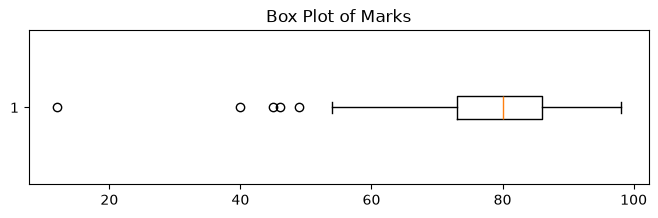

In [22]:
# Display the box plot of marks
plt.figure(figsize=(8,2))
plt.boxplot(df["marks"], vert=False)
plt.title("Box Plot of Marks")
plt.show()

#### What to Analyze

- Are there any outliers?
- How spread is the data?
- Where is the median located?

#### Why It Matters for Machine Learning

- Detect remaining outliers.
- Decide whether outliers should be kept, removed, or capped.
- Understand the spread of the target variable.

### Numerical Feature Analysis

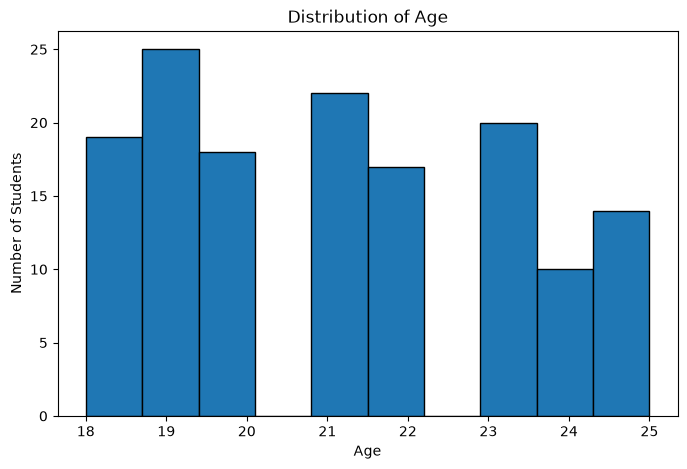

In [23]:
# Display the distribution of age
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=10, edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()

#### What to Observe

- Which age group contains the most students?
- Are ages spread across different groups?
- Are there any unusual ages?

#### Why It Matters

- Helps us understand this feature before model training.
- Confirms that the cleaned data looks reasonable.

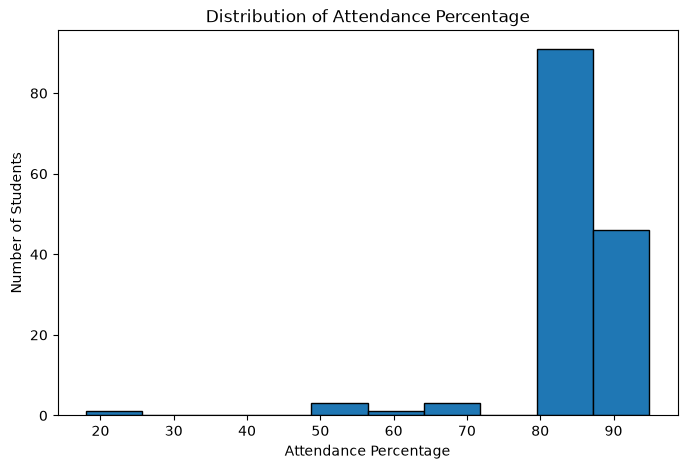

In [24]:
# Display the distribution of attendance percentage
plt.figure(figsize=(8,5))
plt.hist(df["attendance_percentage"], bins=10, edgecolor="black")
plt.title("Distribution of Attendance Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.show()

#### What to Observe

- Are most students' attendance percentages high or low?
- Is attendance evenly distributed?
- Are there unusual attendance values?

#### Why It Matters

- Helps determine whether attendance may be an important feature for prediction.

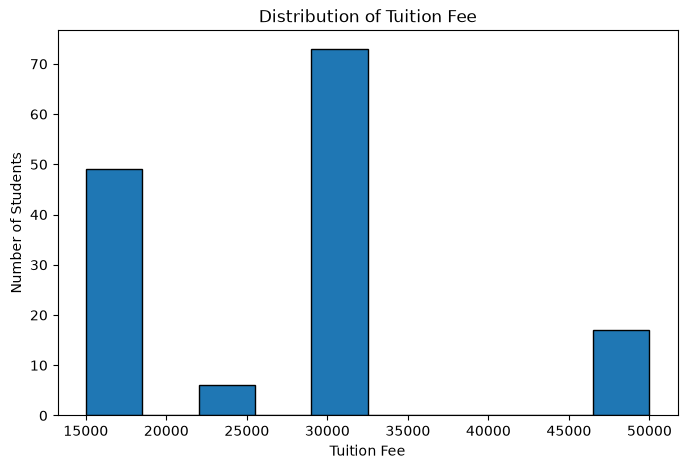

In [25]:
# Display the distribution of tuition fee
plt.figure(figsize=(8,5))
plt.hist(df["tuition_fee"], bins=10, edgecolor="black")
plt.title("Distribution of Tuition Fee")
plt.xlabel("Tuition Fee")
plt.ylabel("Number of Students")
plt.show()

#### What to Observe

- Are tuition fees similar for most students?
- Are there unusually high or low fees?

#### Why It Matters

- Helps understand the feature distribution.
- Indicates whether additional preprocessing may be needed.

### Categorical Feature Analysis

In [26]:
# Display the frequency of gender
df["gender"].value_counts()

gender
male      90
female    55
Name: count, dtype: int64

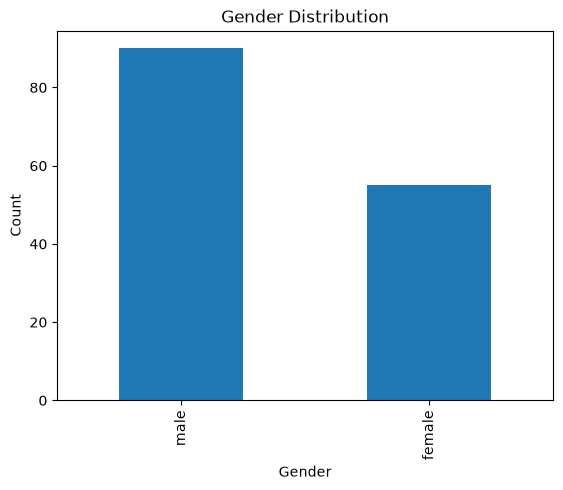

In [27]:
# Visualize the distribution of gender
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

#### What to Observe

- How many Male and Female students are present?
- Are both categories reasonably represented?

#### Why It Matters

- Helps understand the distribution of categorical data.
- Indicates whether one category has significantly fewer samples than the other.

In [28]:
# Display the frequency of departments
df["department"].value_counts()

department
CS    36
IT    34
SE    29
AI    27
DS    19
Name: count, dtype: int64

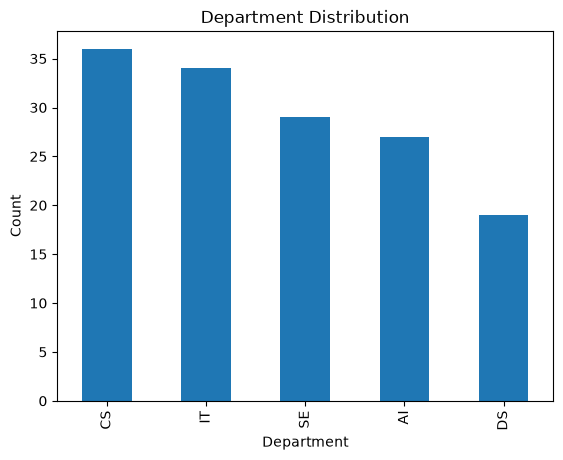

In [29]:
# Visualize the distribution of departments
df["department"].value_counts().plot(kind="bar")
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

#### What to Observe

- Which department has the most students?
- Which department has the fewest students?

#### Why It Matters

- Helps understand the distribution of departments.
- Identifies categories that will later require encoding.

In [30]:
# Display the frequency of semesters
df["semester"].value_counts().sort_index()

semester
1    23
2    20
3    20
4    22
5    18
6    15
7    15
8    12
Name: count, dtype: int64

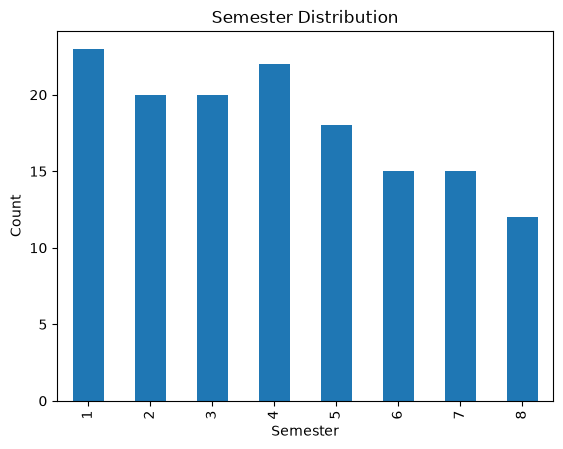

In [31]:
# Visualize the distribution of semesters
df["semester"].value_counts().sort_index().plot(kind="bar")
plt.title("Semester Distribution")
plt.xlabel("Semester")
plt.ylabel("Count")
plt.show()

#### What to Observe

- Which semesters contain the most students?
- Are students evenly distributed across semesters?

#### Why It Matters

- Helps understand the distribution of semester data.
- Confirms that the cleaned data follows the expected business rules.